In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import torch
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error
from random import randrange
import json

from scipy.linalg import svdvals, norm
from scipy.special import softmax
from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util \
    import MetaData, NTKCalculator, StepCalculatorBase, StepCalculatorEtaNtk, StepCalculatorEtaAveragedNtk
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torchvision.datasets import EMNIST
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_step_softmax_loss_eminst.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s",
                datefmt="%m/%d/%Y %I:%M:%S")


#### MNIST dataset

MNIST dataset is used which contains 60000 28x28 images of handwritten digits from 0 to 9. 

In [3]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root=DATASET_PATH, split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root=DATASET_PATH, split='letters', train=False, download=True, transform=image_transform)
#train_dataset = MNIST(root=DATASET_PATH, train=True, download=True, transform=image_transform)
#test_dataset = MNIST(root=DATASET_PATH, train=False, download=True, transform=image_transform)

In [4]:
BATCH_SIZE = 96 #96 #96 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

Data example:

Feature batch shape: torch.Size([96, 1, 28, 28])
Labels batch shape: torch.Size([96])
Labels: [[9, 4, 7, 16, 11, 23, 13, 4], [19, 26, 25, 5, 2, 25, 24, 2], [7, 7, 11, 22, 11, 12, 19, 14], [25, 13, 25, 16, 11, 10, 15, 18], [22, 9, 2, 9, 11, 25, 6, 15], [12, 5, 15, 22, 19, 18, 23, 4], [25, 13, 18, 26, 5, 17, 16, 20], [16, 7, 2, 17, 11, 4, 2, 26], [6, 12, 17, 14, 23, 13, 20, 15], [8, 1, 8, 23, 7, 1, 13, 9], [19, 22, 23, 20, 14, 7, 23, 23], [14, 10, 26, 24, 16, 11, 4, 21]]


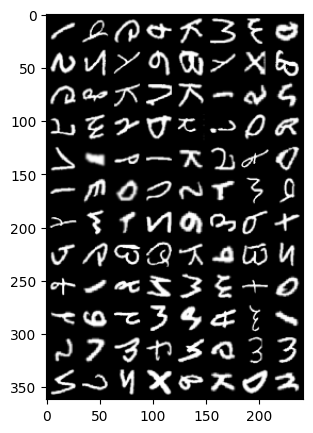

In [5]:
GRID_ROW_SIZE=8
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
#img = train_features[0].squeeze()
images = make_grid(train_features, GRID_ROW_SIZE).permute(1, 2, 0)
labels = train_labels.view(-1, GRID_ROW_SIZE).tolist()
print(f"Labels: {labels}")
plt.figure(figsize=(10, 5))
plt.imshow(images, cmap="gray")
plt.show()


In [6]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 26 #26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 1000, 400 #500, 200 #1000, 400 #500, 200 #250, 100

lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available


##### UTILS

In [7]:
def save_dict(dict, dir):
    with open(dir + "/history.json", "w") as ff:
        ff.write(json.dumps(dict))
        ff.close()

def load_dict(dir):
    with open(dir + "/history.json", "r") as ff:
        dict = json.load(ff)
        ff.close()
        return dict

def flatten2d(HL):  #HL - [output_dim, output_dim, batch_size, batch_size]
    tmp = np.moveaxis(HL, 1, 2)
    dim = tmp.shape
    return np.reshape(tmp, (dim[0]*dim[1], dim[2]*dim[3]))

#def delta(i1, i2):
#    return 1 if i1 == i2 else 0

def NTK_softmax(HL, qq):
    NL = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
    for mm, nn, alpha, beta in itr.product(range(OUTPUT_DIM), range(OUTPUT_DIM), range(BATCH_SIZE), range(BATCH_SIZE)):
        NL[mm, nn, alpha, beta] = np.sum([((1 if m2 == nn else 0) - qq[m2, beta])*qq[nn, beta]*HL[mm, m2, alpha, beta] \
                                          for m2 in range(OUTPUT_DIM)])
        #for m2 in range(OUTPUT_DIM):
        #    NL[mm, nn, alpha, beta] += (delta(m2, nn) - qq[m2, beta])*qq[nn, beta]*HL[mm, m2, alpha, beta]
    return NL

def NTK_softmaxV2(HL, qq, meta):
    SM = (np.identity(meta.output_dim)[:,:,None] - qq[:,None,:])*qq[None,:,:]
    return np.sum(SM[None,:,:,None,:]*HL[:,:,None,:,:], axis=1)

def reduce_tensor_to_active(TS_FULL, pp):
    return np.sum(TS_FULL[:,:,:,:]*pp[None,:,None,:], axis = 1)

def reduce_to_active(MX_FULL, pp):
    return np.sum(MX_FULL*pp, axis=0)

def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    axes[1, 1].set_title('Singular values for flattened NTK')
    #axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['train_ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    
    plt.show()


In [8]:
'''
import time

calc0 = NTKCalculator(meta)
print("calculating step forward1 at {}".format(time.localtime()))
testNet.grad_zero
logits = testNet.forward_(xx)
print("calculating derivatives1 at {}".format(time.localtime()))
calc0.calculate_derivatives(testNet, logits)
print("calculating step forward2 at {}".format(time.localtime()))
testNet.grad_zero
logits2 = testNet.forward_(xx)
print("calculating derivatives2 at {}".format(time.localtime()))
#torch.autograd.backward(logits2)
dummy = torch.autograd.grad((logits2[0,0],logits2[0,1]), (testNet.input_fc.weight, testNet.input_fc.bias\
                                            , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                            , testNet.output_fc.weight, testNet.output_fc.bias)\
                , retain_graph=True, create_graph=True, allow_unused=True)
#logits2.sum().backward()
print("Finish at {}".format(time.localtime()))
'''
'''
print("calculating derivatives at {}".format(time.localtime()))
calc0.calculate_derivatives(testNet, logits)
print("calculating NTK at {}".format(time.localtime()))
HL = calc0.calculate_NTK()
print("calculating the rest at {}".format(time.localtime()))
pp = labels_to_softhot(labels, meta.output_dim)  
qq = softmax(np.transpose(logits.detach()), axis=(0))
SM = (np.identity(meta.output_dim)[:,:,None] - qq[:,None,:])*qq[None,:,:]
NL_FULL = np.sum(SM[None,:,:,None,:]*HL[:,:,None,:,:], axis=1)
'''

'\nprint("calculating derivatives at {}".format(time.localtime()))\ncalc0.calculate_derivatives(testNet, logits)\nprint("calculating NTK at {}".format(time.localtime()))\nHL = calc0.calculate_NTK()\nprint("calculating the rest at {}".format(time.localtime()))\npp = labels_to_softhot(labels, meta.output_dim)  \nqq = softmax(np.transpose(logits.detach()), axis=(0))\nSM = (np.identity(meta.output_dim)[:,:,None] - qq[:,None,:])*qq[None,:,:]\nNL_FULL = np.sum(SM[None,:,:,None,:]*HL[:,:,None,:,:], axis=1)\n'

In [9]:
#print(dummy[5])
#print(testNet.input_fc.bias.grad.shape, calc0.input_dbias.shape)
#print(testNet.input_fc.bias.grad[0], np.sum(calc0.input_dbias[:,:,0]))


In [10]:
#calc0.output_dbias[1,0]

In [11]:
'''
print(NL_FULL.shape, pp.shape)
#pp
pp_argmax = pp.argmax(axis=0)
#mask = 
NL = np.sum(NL_FULL[:,:,:,:]*pp[None,:,None,:], axis = 1)
#print(NL_FULL[2,:,2,10], NL[2,2,10], pp_argmax[10])
'''

'\nprint(NL_FULL.shape, pp.shape)\n#pp\npp_argmax = pp.argmax(axis=0)\n#mask = \nNL = np.sum(NL_FULL[:,:,:,:]*pp[None,:,None,:], axis = 1)\n#print(NL_FULL[2,:,2,10], NL[2,2,10], pp_argmax[10])\n'

In [12]:

'''
ID = reduce_matrix_to_active(calc0.calculate_ID(), pp)
ID.shape

delta = pp - qq
RES = np.tensordot(ID - 0.01*NL_FULL, delta, axes=([0,2],[0,1]))
'''

'\nID = reduce_matrix_to_active(calc0.calculate_ID(), pp)\nID.shape\n\ndelta = pp - qq\nRES = np.tensordot(ID - 0.01*NL_FULL, delta, axes=([0,2],[0,1]))\n'

In [13]:
##Step calculates η minimising (∞.86) softmax-analogue with 2-matrix norm. 
## Parameters change is according to (7.11) for cross-enthropy loss
class StepCalculatorEtaSoftmaxNtk(StepCalculatorBase):
    def __init__(self, meta, ntk_recalc_steps_period = 5):
        super().__init__()
        self.meta = meta
        self.ntk_recalc_steps_period = ntk_recalc_steps_period

    def step(self, testNet, labels, logits, etas):
        meta = self.meta
        logits_detached = logits.detach()
        pp = labels_to_softhot(labels, meta.output_dim)  
        qq = softmax(np.transpose(logits_detached), axis=(0))
        delta = pp - qq

        calc0 = NTKCalculator(meta)
        calc0.calculate_derivatives(testNet, logits)
        do_calc_eta = (etas[0] == 0.0 or self.ntk_recalc_steps_period <= 0)
        if (do_calc_eta == False):
            do_calc_eta = randrange(self.ntk_recalc_steps_period) == 0

        HL, NL = None, None
        #eta = 0.01

        if (do_calc_eta):
            logging.info("##Calculating NTK by (8.4)")
            HL = calc0.calculate_NTK()
            logging.info("##Calculating NTK softmax")
            NL = NTK_softmaxV2(HL, qq, meta)
            #NL = reduce_matrix_to_active(NL_FULL, pp)
            ID = calc0.calculate_ID()
            logging.info("##Calculating η minimising (∞.86)")
            fun = lambda eta: norm(reduce_to_active(np.tensordot(ID - eta*NL, delta, axes=([0,2],[0,1])), pp), ord=2)#ord=2 ord='fro')
            res = minimize_scalar(fun, bounds=(0, 1000))
            logging.info("##Optimal point found: {}".format(res))
            logging.info("##Step ratio: {}".format(res.fun/norm(reduce_to_active(delta, pp), ord=2)))
            if etas[0] == 0.0:
                etas[1] = res.x
            else:
                etas[1] = etas[0]
            etas[0] = res.x
            eta = res.x
        else:
            eta = round(0.6 * etas[0] + 0.4 * etas[1], 5);
            logging.info("##Using previous eta value={}".format(eta))

        #etas = [eta, eta]
        term = eta*delta
        self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * meta.lw_input()
        self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden()
        self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * meta.lw_output()
        self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * meta.lb

        self.do_step0(testNet)
        return etas, HL, NL

##Step calculates η minimising (∞.86) softmax-analogue with 2-matrix norm. 
## Parameters change is according to (7.11) for cross-enthropy loss, step is adjusted by Armiho condition
class StepCalculatorEtaSoftmaxArmihoNtk(StepCalculatorBase):
    def __init__(self, meta):
        super().__init__()
        self.meta = meta
        self.step_one = 1.0
        self.step_deltas = [3.0, -2.0, -0.5, -0.5, -0.5, -0.25, -0.125, -0.0625, -0.03125, -0.015625]

    def step(self, testNet, labels, xx):
        meta = self.meta
        testNet.grad_zero
        logits = testNet.forward_(xx)

        logits_detached = logits.detach().numpy()
        pp = labels_to_softhot(labels, meta.output_dim)  
        qq = softmax(np.transpose(logits_detached), axis=(0))
        delta = pp - qq

        calc0 = NTKCalculator(meta)
        calc0.calculate_derivatives(testNet, logits)
        #do_calc_eta = (etas[0] == 0.0 or self.ntk_recalc_steps_period <= 0)
        #if (do_calc_eta == False):
        #    do_calc_eta = randrange(self.ntk_recalc_steps_period) == 0

        HL, NL = None, None
        #eta = 0.01

        #if (do_calc_eta):
        logging.info("##Calculating NTK by (8.4)")
        HL = calc0.calculate_NTK()
        logging.info("##Calculating NTK softmax")
        NL = NTK_softmaxV2(HL, qq, meta)
        #NL = reduce_matrix_to_active(NL_FULL, pp)
        ID = calc0.calculate_ID()
        logging.info("##Calculating η minimising (∞.86)")
        fun = lambda eta: norm(reduce_to_active(np.tensordot(ID - eta*NL, delta, axes=([0,2],[0,1])), pp), ord=2)#ord=2 ord='fro')
        res = minimize_scalar(fun, bounds=(0, 1000))
        logging.info("##Optimal point found: {}".format(res))
        eta = res.x
        delta1 = reduce_to_active(np.tensordot(ID - eta*NL, delta, axes=([0,2],[0,1])), pp)
        delta0 = reduce_to_active(delta, pp)
        #logging.info("##Step ratio: {}".format(res.fun/norm(delta0, ord=2)))
        #else:
        #    eta = round(0.6 * etas[0] + 0.4 * etas[1], 5);
        #    logging.info("##Using previous eta value={}".format(eta))

        #etas = [eta, eta]
        term = eta*delta
        self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * meta.lw_input()
        self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden()
        self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * meta.lw_output()
        self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * meta.lb

        initialLoss = -np.sum(pp * np.log(qq))/meta.batch_size
        ratio = reduce_to_active(pp/qq, pp)
        delta_delta_est = delta1 - delta0 #delta = pp - qq, we consider pp/qq without -
        #logging.info("qq0: {}".format(reduce_to_active(qq, pp)))
        #logging.info("qq1 linear estimation: {}".format(-delta_delta))
        diff_est = np.dot(ratio, delta_delta_est)
        initialPqRatio = res.fun/norm(delta0, ord=2)
        logging.info("##Initial loss = {}".format(initialLoss))
        logging.info("##With linear qq-approximation: diff_init = {}, (p-q)ratio = {}".format(diff_est, initialPqRatio))

        #Armiho: Loss(θ+α) <= c1*α*∇Loss(θ) + Loss(θ)
        #Wolf: |∇Loss(θ+α)| <= c2*|∇Loss(θ)|
        #0<c1<c2<1
        #Additional condition: ∇Loss(θ+α) <= c3*|∇Loss(θ)| , 0<c3<1 (Significant loss growth at the final point is unacceptable)
        c1 = 0.000005 #0.000025
        c2 = 0.75
        c3 = 0.1

        self.do_step0(testNet, self.step_one)
        logits_one = testNet.forward_(xx)
        qq_one = softmax(np.transpose(logits_one.detach().numpy()), axis=(0))
        delta_delta_one = reduce_to_active(qq - qq_one, pp) #We consider pp/qq without -

        logits_k = None
        aa = self.step_one
        with torch.no_grad():
            for step_delta in self.step_deltas:
                if (step_delta != 0.0):
                    aa += step_delta
                    self.do_step0(testNet, step_delta)
                logits_k = testNet.forward_(xx)
                qq_k = softmax(np.transpose(logits_k.detach().numpy()), axis=(0))
                #logging.info("qq1 factual: {}".format(reduce_to_active(qq_k, pp)))
                loss_k = -np.sum(pp * np.log(qq_k))/meta.batch_size
                ratio_k = reduce_to_active(pp/qq_k, pp)
                delta_k = reduce_to_active(pp - qq_k, pp)
                pq_ratio_k = norm(delta_k, ord=2)/norm(delta0, ord=2)
                diff_est_k = np.dot(ratio_k, delta_delta_est) #∇L(θ+α)
                logging.info("##Step with aa: {}, loss_k: {}, diff_k from linear qq-approximation: {}, "\
                             .format(aa, loss_k, diff_est_k))
                
                diff_fact = np.dot(ratio, delta_delta_one)
                diff_fact_k = np.dot(ratio_k, delta_delta_one)
                logging.info("##With factual qq_k: diff_init = {}, diff_k = {}, (p-q)ratio: {}"\
                            .format(diff_fact, diff_fact_k, pq_ratio_k))
                condition_armiho = loss_k <= initialLoss + c1*aa*diff_fact
                condition_wolf = abs(diff_fact_k) <= c2*abs(diff_fact)
                condition_additional = diff_fact_k <= c3*abs(diff_fact)
                logging.info("##Conditions: armiho = {}, wolf = {}, additional = {}, "\
                             .format(condition_armiho, condition_wolf, condition_additional))
                if condition_armiho and condition_wolf and condition_additional:
                    break

        return [eta*aa,eta*aa], HL, logits_k

    def step_withNtk(self, testNet, labels, logits, HL):
        meta = self.meta
        logits_detached = logits.detach()
        pp = labels_to_softhot(labels, meta.output_dim)  
        qq = softmax(np.transpose(logits_detached), axis=(0))
        delta = pp - qq

        calc0 = NTKCalculator(meta)
        calc0.calculate_derivatives(testNet, logits)
        #do_calc_eta = (etas[0] == 0.0 or self.ntk_recalc_steps_period <= 0)
        #if (do_calc_eta == False):
        #    do_calc_eta = randrange(self.ntk_recalc_steps_period) == 0

        logging.info("##Calculating NTK by (8.4)")
        #HL = calc0.calculate_NTK()
        logging.info("##Calculating NTK softmax")
        NL = NTK_softmaxV2(HL, qq, meta)
        ID = calc0.calculate_ID()
        logging.info("##Calculating η minimising (∞.86)")
        #fun = lambda eta: norm(np.tensordot(ID - eta*NL, delta, axes=([0,2],[0,1])), ord='fro')
        fun = lambda eta: norm(reduce_to_active(np.tensordot(ID - eta*NL, delta, axes=([0,2],[0,1])), pp), ord=2)
        res = minimize_scalar(fun, bounds=(0, 1000))
        logging.info("##Optimal point found: {}".format(res))
        logging.info("##Step ratio: {}".format(res.fun/norm(delta, ord=2)))
        eta = res.x

        #etas = [eta, eta]
        term = eta*delta
        self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=([0,1],[0,1])) * meta.lw_input()
        self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden()
        self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=([0,1],[0,1])) * meta.lb
        self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=([0,1],[0,1])) * meta.lw_output()
        self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=([0,1],[0,1])) * meta.lb
        
        self.do_step0(testNet)
        return eta, NL


#### FFN

Typical implementation of image-recognition

FFN with 2 hidden layers: 
- nn.ReLU is an activation-function
- nn.

Cross-entropy loss and stochastic gradient descent optimiser are used. Descent is performed in number of epochs, no stop-criterion for gradient descent. Accuracy is the metric for the learninng process.

#### Experiment with FFN in criticality mode for relu

In [14]:
NUM_EPOCH = 1 #00
NTK_RECALC_STEPS_PERIOD = 0
NEW_START = False
HISTORY_PARAMS = collections.defaultdict(list)

#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
if NEW_START:
    testNet.init_weights(cb, cw)
else:
    testNet.init_weights_txt('#current_saved/accuracy_eta_calculated')
    HISTORY_PARAMS = load_dict('#current_saved/accuracy_eta_calculated')
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=1000, bias=True)
  (hidden_fc): Linear(in_features=1000, out_features=400, bias=True)
  (output_fc): Linear(in_features=400, out_features=26, bias=True)
)

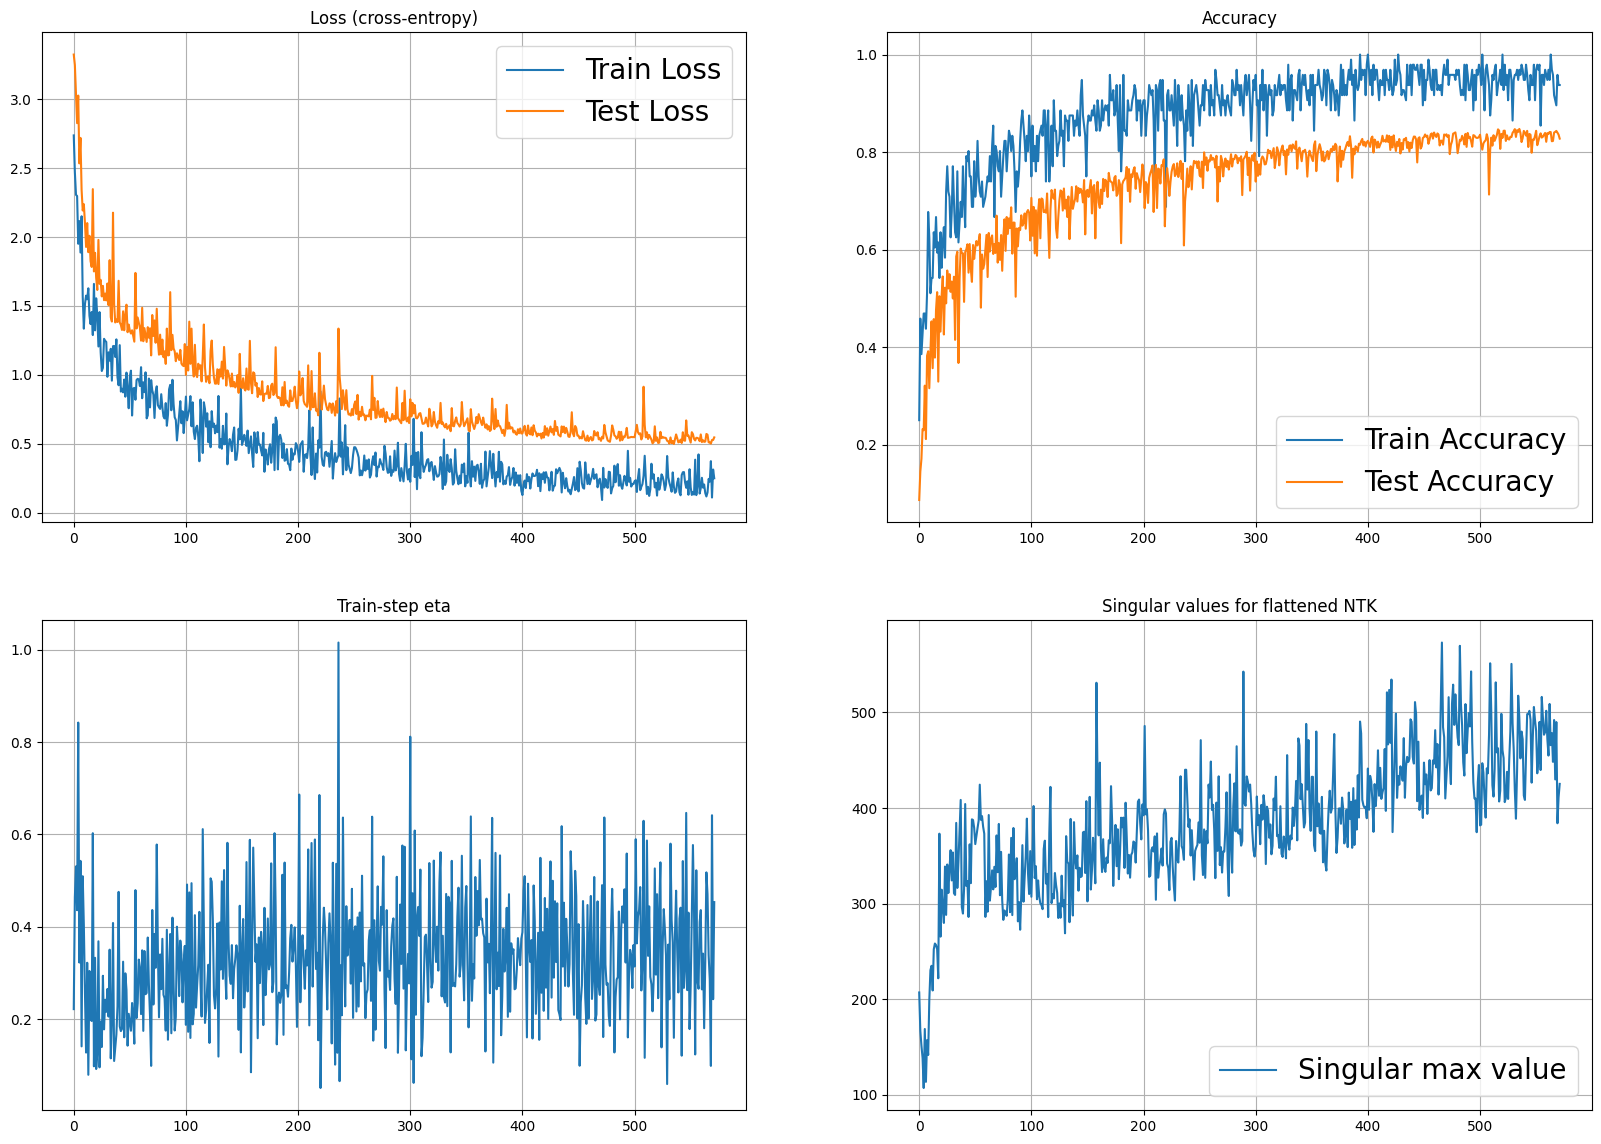

Test accuracy = 0.8275489635456542


In [ ]:
etas = [0.0, 0.0]
sungular_latest = 0.0
stepCalc0 = StepCalculatorEtaSoftmaxArmihoNtk(meta) #StepCalculatorEtaSoftmaxNtk(meta, ntk_recalc_steps_period = NTK_RECALC_STEPS_PERIOD)
epoch_count = 0
for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    # Check implementation in `utils.py`
    #train_loss_meter, train_accuracy_meter, eta_meter, singular_meter = \
    #    AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        #if iter_number >= 1:
        #    break
        iter_number += 1
        images, labels_raw = train_batch
        #if iter_number == 1:
        #    print("!!", labels_raw[0])
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        #testNet.grad_zero
        #logits = testNet.forward_(xx)
        #logits, HL_torch = testNet.forward_ntk(xx) #.forward_(xx)
        #HL = HL_torch.detach().numpy()

        etas, HL_latest, logits = stepCalc0.step(testNet, labels, xx) #stepCalc0.step(testNet, labels, logits, etas)
        #eta, NL = stepCalc0.step_withNtk(testNet, labels, logits, HL)
        #eta_meter.update(etas[0])

        if not(HL_latest is None):
            HL2d = flatten2d(HL_latest)
            sungular_latest = np.max(svdvals(HL2d))
        #singular_meter.update(0) #(sungular_latest)

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits.detach().numpy())
        prediction = logits.argmax(dim=-1).detach()
        loss = loss_crossentropy(zz_logits, labels)
        #train_loss_meter.update(loss)
        #train_accuracy_meter.update(
        #    calculate_accuracy(
        #        prediction,
        #        labels
        #    )
        #)
        # save average train loss and accuracy
        HISTORY_PARAMS['train_loss'].append(loss) #(train_loss_meter.avg)
        HISTORY_PARAMS['train_accuracy'].append(calculate_accuracy(prediction,labels)) #(train_accuracy_meter.avg)
        HISTORY_PARAMS['train_eta'].append(etas[0]) #(eta_meter.avg)
        HISTORY_PARAMS['train_ntk_sungular_max'].append(sungular_latest) #(singular_meter.avg)

        # testing loop
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
        for test_batch in test_dataloader:
            images, labels_raw = test_batch
            labels = torch.tensor([x-1 for x in labels_raw])
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                # do everything like we did in training loop
                batch_size = images.shape[0]
                xx = images.view(batch_size, -1)
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(
                    calculate_accuracy(
                        prediction,
                        labels
                    )
                )

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS)
        print("Test accuracy = {}".format(test_accuracy_meter.avg))
        
        if iter_number >= 10:
            testNet.save_txt('#current_saved/accuracy_eta_calculated')
            save_dict(HISTORY_PARAMS, '#current_saved/accuracy_eta_calculated')
            iter_number = 0

    '''
        epoch_count = 0
    else:
        epoch_count += 1
    '''
     

In [185]:
'''
qq = softmax(np.transpose(logits.detach()), axis=(0))
print("#Calculating V2")
NLv2 = NTK_softmaxV2(HL_latest, qq, meta)
print("#Calculated V2 avg is {}".format(np.average(NLv2)))
print("#Calculating V1")
NL = NTK_softmax(HL_latest, qq)
print("#Calculated V1 avg is {}".format(np.average(NL)))

NL_delta = NLv2-NL
print(np.max((NL)), np.min((NL)), np.average((NL)))
print(np.max((NLv2)), np.min((NLv2)), np.average((NLv2)))
print(np.max(np.abs(NL_delta)), np.average((NL_delta)))
'''

#Calculating V2
#Calculated V2 avg is -1.7678721480310105e-12
#Calculating V1
#Calculated V1 avg is -1.767872136942497e-12


In [ ]:
testNet.save_txt('#current_saved/accuracy_eta_calculated')
save_dict(HISTORY_PARAMS, '#current_saved/accuracy_eta_calculated')

In [12]:
print("Accuracy achieved in FFN at Relu-criticality: "+str(HISTORY_PARAMS['test_accuracy'][-1]))

Accuracy achieved in FFN at Relu-criticality: 0.8536626342254849
